# Toronto Rental Market Analysis

This notebook analyzes rental prices and vacancy rates across Toronto rental market zones using CMHC data for 2024 and 2025.

# Objectives

- Examine the relationship between rental prices and vacancy rates.
- Compare market conditions across bedroom types.
- Analyze changes in rent and vacancy rates from 2024 to 2025.
- Identify Toronto rental zones with unusual market conditions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Data

The analysis uses two cleaned CMHC datasets: average rental prices and vacancy rates by Toronto rental market zone and bedroom type.

In [18]:
rent = pd.read_csv("/Users/owais/Documents/Toronto-Rental-Market-Analyzer/data/clean_rent_data.csv")
vacancy = pd.read_csv("/Users/owais/Documents/Toronto-Rental-Market-Analyzer/data/clean_vacancy.csv")

## 2. Data Validation

Before analysis, the datasets are checked for their dimensions, data types, and missing values.

In [19]:
print("Rent dataset shape:", rent.shape)
print("Vacancy dataset shape:", vacancy.shape)

Rent dataset shape: (68, 7)
Vacancy dataset shape: (68, 5)


In [20]:
print("Rent columns:")
print(rent.columns)

print("\nVacancy columns:")
print(vacancy.columns)

Rent columns:
Index(['zone', 'area', 'bedroom_type', 'rent_2024', 'rent_2025',
       'dollar_change', 'percent_change'],
      dtype='object')

Vacancy columns:
Index(['zone', 'area', 'bedroom_type', 'vacancy_2024', 'vacancy_2025'], dtype='object')


In [ ]:
rent.dtypes

zone              int64
area             object
bedroom_type     object
vacancy_2024    float64
vacancy_2025    float64
dtype: object

In [25]:
vacancy.dtypes

zone              int64
area             object
bedroom_type     object
vacancy_2024    float64
vacancy_2025    float64
dtype: object

## 3. Merge Rent and Vacancy Data

The rent and vacancy datasets are merged by zone, area, and bedroom type to analyze the relationship between rental prices and vacancy rates.

In [ ]:
df = pd.merge(
    rent,
    vacancy,
    on=["zone", "area", "bedroom_type"],
    how="inner"
)

#check null values and duplicates, some null is fine, duplicate should be 0
df.isnull().sum()

df.duplicated(subset=["zone", "bedroom_type"]).sum()


np.int64(0)

In [ ]:
#check if merge worked
df.head(10)

,zone,area,bedroom_type,rent_2024,rent_2025,dollar_change,percent_change,vacancy_2024,vacancy_2025
0,1,Toronto (Central),Studio,1574.0,1606.0,32.0,2.0,4.2,3.6
1,1,Toronto (Central),1 Bedroom,1968.0,2042.0,74.0,3.8,3.5,2.4
2,1,Toronto (Central),2 Bedroom,2627.0,2776.0,149.0,5.7,2.8,2.9
3,1,Toronto (Central),3 Bedroom+,3494.0,3580.0,86.0,2.5,4.2,4.0
4,2,Toronto (East),Studio,1166.0,1213.0,47.0,4.0,5.8,NaN
5,2,Toronto (East),1 Bedroom,1627.0,1692.0,65.0,4.0,3.4,3.7
6,2,Toronto (East),2 Bedroom,1967.0,1869.0,-98.0,-5.0,0.9,1.3
7,2,Toronto (East),3 Bedroom+,NaN,NaN,NaN,NaN,NaN,NaN
8,3,Toronto (North),Studio,1570.0,1570.0,0.0,0.0,2.8,4.4
9,3,Toronto (North),1 Bedroom,1889.0,1892.0,3.0,0.2,2.3,3.3


## 4. Rent and Vacancy Relationship

This section examines whether rental prices and vacancy rates are related across Toronto rental market zones.

In [35]:
correlation = df["rent_2025"].corr(df["vacancy_2025"])

print("Correlation between 2025 rent and vacancy:", round(correlation, 3))

Correlation between 2025 rent and vacancy: -0.427


In [37]:
correlation_by_bedroom = (
    df.groupby("bedroom_type")
      .apply(
          lambda x: x["rent_2025"].corr(x["vacancy_2025"]),
          include_groups=False
      )
)

correlation_by_bedroom

bedroom_type
1 Bedroom    -0.370830
2 Bedroom     0.552058
3 Bedroom+    0.766524
Studio       -0.026047
dtype: float64

### Interpretation

The relationship between rent and vacancy rates varies by bedroom type. One-bedroom units show a moderate negative correlation (-0.371), suggesting that higher rents tend to be associated with lower vacancy rates. In contrast, two-bedroom units show a moderate positive correlation (0.552), while three-bedroom and larger units show a strong positive correlation (0.767). Studio units show almost no linear relationship (-0.026).

These results suggest that the relationship between rent and vacancy is not consistent across Toronto's rental market and may depend on unit size. These correlations show associations and do not indicate that rent levels cause changes in vacancy rates.

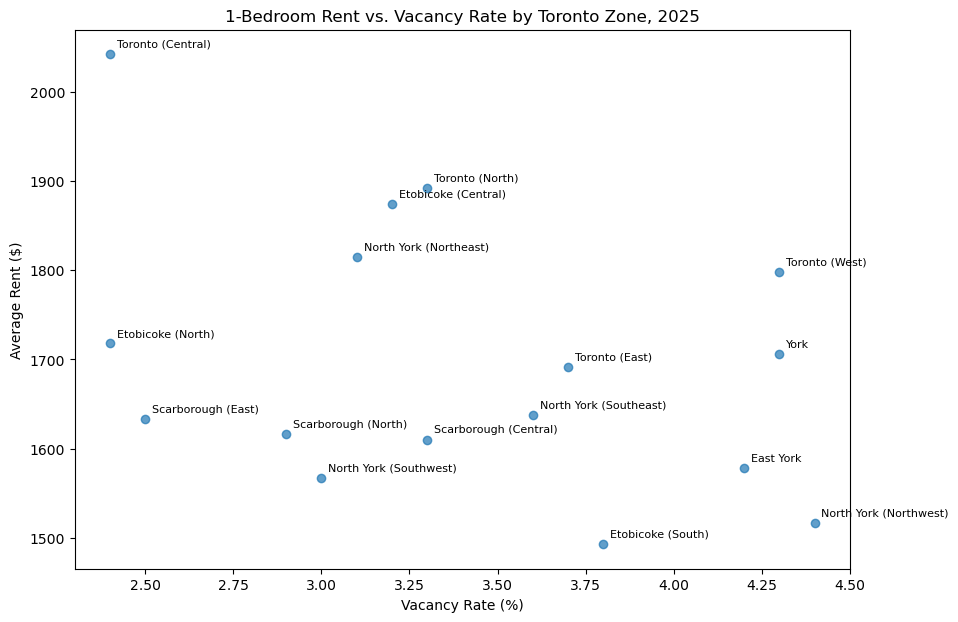

In [39]:
plt.figure(figsize=(10, 7))

plt.scatter(
    one_bedroom["vacancy_2025"],
    one_bedroom["rent_2025"],
    alpha=0.7
)

for _, row in one_bedroom.iterrows():
    plt.annotate(
        row["area"],
        (row["vacancy_2025"], row["rent_2025"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Vacancy Rate (%)")
plt.ylabel("Average Rent ($)")
plt.title("1-Bedroom Rent vs. Vacancy Rate by Toronto Zone, 2025")

plt.show()

### 1-Bedroom Market Interpretation

The scatterplot shows a moderate negative relationship between 1-bedroom rents and vacancy rates (r = -0.371). Toronto (Central) stands out with the highest average rent and one of the lowest vacancy rates. Several areas with higher vacancy rates, including North York (Northwest) and Etobicoke (South), have comparatively lower rents.

However, the relationship is not consistent across all zones. For example, Toronto (West) has both a relatively high vacancy rate and a relatively high average rent. This variation suggests that vacancy alone does not explain differences in rental prices across Toronto.

## 5. Year-over-Year Market Changes

This section examines whether changes in vacancy rates from 2024 to 2025 are associated with changes in rental prices over the same period.

In [42]:
df["vacancy_change_pp"] = df["vacancy_2025"] - df["vacancy_2024"]

In [43]:
df[
    [
        "area",
        "bedroom_type",
        "percent_change",
        "vacancy_change_pp"
    ]
].head(10)

,area,bedroom_type,percent_change,vacancy_change_pp
0,Toronto (Central),Studio,2.0,-0.6
1,Toronto (Central),1 Bedroom,3.8,-1.1
2,Toronto (Central),2 Bedroom,5.7,0.1
3,Toronto (Central),3 Bedroom+,2.5,-0.2
4,Toronto (East),Studio,4.0,NaN
5,Toronto (East),1 Bedroom,4.0,0.3
6,Toronto (East),2 Bedroom,-5.0,0.4
7,Toronto (East),3 Bedroom+,NaN,NaN
8,Toronto (North),Studio,0.0,1.6
9,Toronto (North),1 Bedroom,0.2,1.0


In [44]:
change_correlation = df["percent_change"].corr(
    df["vacancy_change_pp"]
)

print(
    "Correlation between rent change and vacancy change:",
    round(change_correlation, 3)
)

Correlation between rent change and vacancy change: 0.03


In [45]:
change_correlation_by_bedroom = (
    df.groupby("bedroom_type")
      .apply(
          lambda x: x["percent_change"].corr(
              x["vacancy_change_pp"]
          ),
          include_groups=False
      )
)

change_correlation_by_bedroom

bedroom_type
1 Bedroom     0.456178
2 Bedroom     0.161155
3 Bedroom+    0.179797
Studio       -0.498049
dtype: float64

### Year-over-Year Change Interpretation

The relationship between changes in rent and vacancy rates also varies by bedroom type. One-bedroom units show a moderate positive correlation (r = 0.456), indicating that larger increases in vacancy tended to occur alongside larger increases in rent.

Studio units show a moderate negative correlation (r = -0.498), meaning that increases in vacancy tended to be associated with smaller rent increases or rent decreases. Two-bedroom (r = 0.161) and three-bedroom+ units (r = 0.180) show only weak positive relationships.

Overall, the results suggest that changes in vacancy rates alone do not consistently explain changes in rental prices across all unit types.

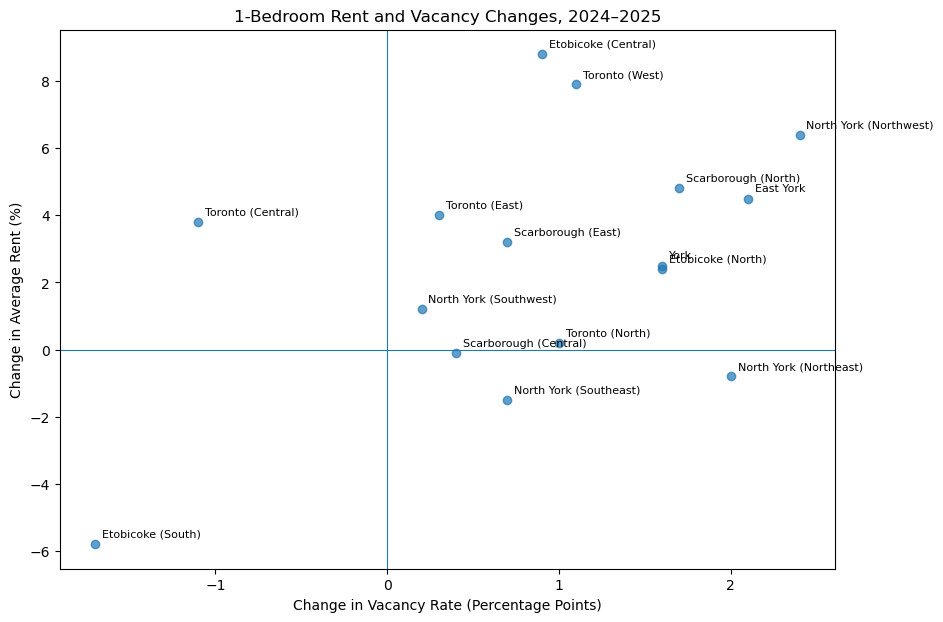

In [46]:
one_bedroom_change = df[
    (df["bedroom_type"] == "1 Bedroom") &
    (df["percent_change"].notna()) &
    (df["vacancy_change_pp"].notna())
]

plt.figure(figsize=(10, 7))

plt.scatter(
    one_bedroom_change["vacancy_change_pp"],
    one_bedroom_change["percent_change"],
    alpha=0.7
)

for _, row in one_bedroom_change.iterrows():
    plt.annotate(
        row["area"],
        (row["vacancy_change_pp"], row["percent_change"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Change in Vacancy Rate (Percentage Points)")
plt.ylabel("Change in Average Rent (%)")
plt.title("1-Bedroom Rent and Vacancy Changes, 2024–2025")

plt.show()

### 1-Bedroom Year-over-Year Interpretation

Most Toronto zones experienced increases in both 1-bedroom rents and vacancy rates from 2024 to 2025. This contributes to the moderate positive correlation (r = 0.456) between changes in rent and vacancy.

However, the pattern was not consistent across all zones. Toronto (Central) experienced an increase in rent while vacancy declined, while some areas experienced increasing vacancy alongside declining rents. These differences show that changes in vacancy rates alone do not explain changes in rental prices across Toronto.

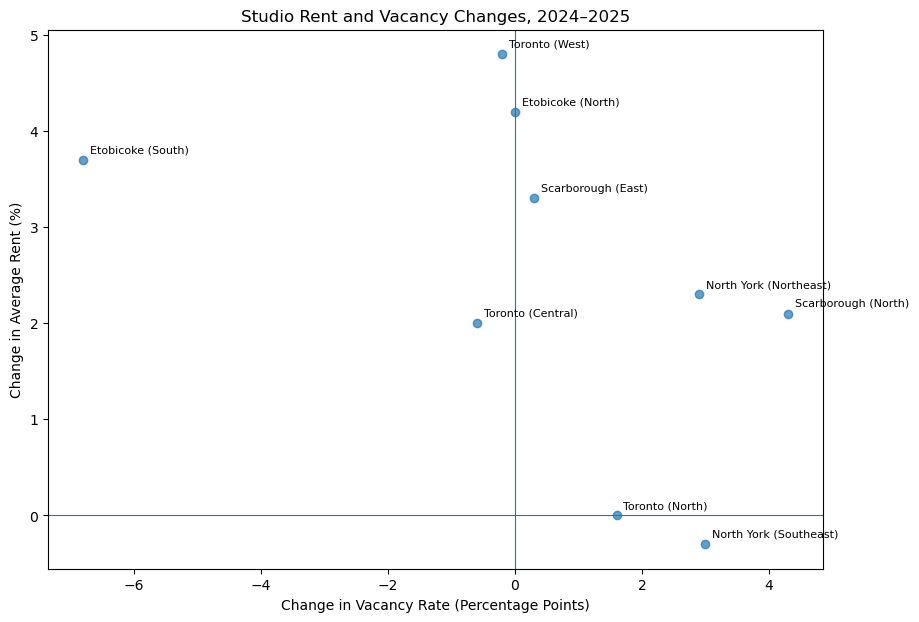

In [47]:
studio_change = df[
    (df["bedroom_type"] == "Studio") &
    (df["percent_change"].notna()) &
    (df["vacancy_change_pp"].notna())
]

plt.figure(figsize=(10, 7))

plt.scatter(
    studio_change["vacancy_change_pp"],
    studio_change["percent_change"],
    alpha=0.7
)

for _, row in studio_change.iterrows():
    plt.annotate(
        row["area"],
        (row["vacancy_change_pp"], row["percent_change"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Change in Vacancy Rate (Percentage Points)")
plt.ylabel("Change in Average Rent (%)")
plt.title("Studio Rent and Vacancy Changes, 2024–2025")

plt.show()

### Studio Year-over-Year Interpretation

Studio units show a moderate negative relationship between changes in rent and vacancy rates (r = -0.498). In general, zones with larger increases in studio vacancy experienced smaller increases in rent.

However, Etobicoke (South) stands out with a substantial decline in vacancy and an increase in rent. Because the number of observations is limited and some zones have suppressed CMHC estimates, the results should be interpreted as exploratory rather than evidence of a broader causal relationship.

In [48]:
studio_without_outlier = studio_change[
    studio_change["area"] != "Etobicoke (South)"
]

studio_correlation_without_outlier = (
    studio_without_outlier["percent_change"]
    .corr(studio_without_outlier["vacancy_change_pp"])
)

print(
    "Studio correlation with all observations:",
    round(
        studio_change["percent_change"].corr(
            studio_change["vacancy_change_pp"]
        ),
        3
    )
)

print(
    "Studio correlation without Etobicoke (South):",
    round(studio_correlation_without_outlier, 3)
)

Studio correlation with all observations: -0.498
Studio correlation without Etobicoke (South): -0.537


### Sensitivity Check

Etobicoke (South) was examined because its change in vacancy rate was noticeably different from the other studio observations. After excluding this observation, the correlation changed from -0.498 to -0.537.

The relationship remained moderately negative and became slightly stronger. This suggests that the negative relationship between changes in studio vacancy rates and rent was not driven solely by the Etobicoke (South) observation.

## 6. Key Findings

- The relationship between 2025 rent and vacancy rates varied considerably by bedroom type. One-bedroom units showed a moderate negative relationship, while two-bedroom and three-bedroom+ units showed positive relationships. Studio units showed almost no relationship.

- For one-bedroom units, Toronto (Central) stood out with the highest average rent and one of the lowest vacancy rates. However, vacancy rates alone did not consistently explain differences in rents across Toronto zones.

- Changes from 2024 to 2025 also differed by unit type. One-bedroom units showed a moderate positive relationship between changes in rent and vacancy, while studio units showed a moderate negative relationship.

- A sensitivity check on the studio analysis showed that removing the unusual Etobicoke (South) observation changed the correlation from -0.498 to -0.537. This suggests that the negative relationship was not driven solely by this observation.

Overall, the analysis suggests that Toronto's rental market behaves differently across unit types. Rent and vacancy are related in some segments, but vacancy alone does not explain rental price levels or changes across Toronto.

In [49]:
df.to_csv("/Users/owais/Documents/Toronto-Rental-Market-Analyzer/data/toronto_rental_combined.csv", index=False)

print("Combined dataset exported successfully.")

Combined dataset exported successfully.
